# EfficientNet-B0 VAE – ISIC 2018 MEL vs NV

In [1]:
!(git -C capstone fetch && git -C capstone reset --hard origin/main) || git clone https://github.com/theantagonist9509/capstone
!mv capstone/datasets.py capstone/custom_datasets.py
!ln -s /kaggle/input/datasets/muplus2sigma/custom-isic2018 dataset

HEAD is now at d98eba3 VAE training code
ln: failed to create symbolic link 'dataset/custom-isic2018': Read-only file system


In [29]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import sys
import glob
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "capstone"))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from custom_datasets import ISIC2018Dataset, TransformDataset
from models import NVMELVAE
from losses import MS_SSIMLoss
from utils import load_best_model, print_checkpoint_info

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

PyTorch 2.10.0+cu128 | CUDA available: True


In [13]:
# ── Parameters (edit here) ────────────────────────────────────────────────────
TRAIN_DATASET_DIR   = "dataset/ISIC_2018/ISIC2018_Task3_Training_Input"
TRAIN_LABELS_CSV    = "dataset/ISIC_2018/ISIC2018_Task3_Training_GroundTruth.csv"

VAL_DATASET_DIR     = "dataset/ISIC_2018/ISIC2018_Task3_Validation_Input"
VAL_LABELS_CSV      = "dataset/ISIC_2018/ISIC2018_Task3_Validation_GroundTruth.csv"

CHECKPOINT_DIR      = "checkpoints/efficientnet_nv_mel_vae"

IMAGE_SIZE      = 224          # EfficientNet-B0 default
BATCH_SIZE      = 16
NUM_WORKERS     = 2
LEARNING_RATE   = 1e-5         # lower LR appropriate for fine-tuning
NUM_EPOCHS      = 30
LABEL_SMOOTHING = 0.3          # aggressive label smoothing
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
LABEL_NAMES     = ["NV", "MEL"]

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Using device  : {DEVICE}")
print(f"Image size    : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Checkpoint dir: {os.path.abspath(CHECKPOINT_DIR)}")

Using device  : cuda
Image size    : 224 x 224
Checkpoint dir: /kaggle/working/checkpoints/efficientnet_nv_mel_vae


In [4]:
# ── Transforms ───────────────────────────────────────────────────────────────
# Train: augmentations to reduce over-fitting on the small MEL class.
# Val  : deterministic centre-crop only.
imagenet_mean   = torch.tensor([0.485, 0.456, 0.406])
imagenet_std    = torch.tensor([0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

print("Transform pipelines defined.")

Transform pipelines defined.


In [5]:
# ── Dataset & DataLoaders ─────────────────────────────────────────────────────

train_dataset = ISIC2018Dataset(
    root_dir       = TRAIN_DATASET_DIR,
    transform      = train_transform,
    labels_csv     = TRAIN_LABELS_CSV,
    include_labels = LABEL_NAMES,
    load_into_memory = True,
)

val_dataset = ISIC2018Dataset(
    root_dir       = VAL_DATASET_DIR,
    transform      = val_transform,
    labels_csv     = VAL_LABELS_CSV,
    include_labels = LABEL_NAMES,
    load_into_memory = True,
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size:   {len(val_dataset)}")

# ── Collect raw one-hot labels for WeightedRandomSampler (no image I/O) ──────
# label_map rows are [NV, MEL]; binary label = argmax
train_labels = [
    int(train_dataset.label_map.loc[
        os.path.splitext(os.path.basename(p))[0]
    ].values.argmax())
    for p in train_dataset.image_paths
]
train_class_counts = np.bincount(train_labels)
print(f"Class counts (train): NV={train_class_counts[0]:,}  MEL={train_class_counts[1]:,}")

# ── WeightedRandomSampler on train split only ─────────────────────────────────
class_weights  = 1.0 / train_class_counts
sample_weights = [class_weights[lbl] for lbl in train_labels]

train_sampler  = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(train_dataset),
    replacement = True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = train_sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

print(f"Train batches/epoch : {len(train_loader)}")
print(f"Val batches         : {len(val_loader)}")

Found 10015 valid images in 'dataset/ISIC_2018/ISIC2018_Task3_Training_Input'
Loading images into memory...
Done loading images into memory.
Found 193 valid images in 'dataset/ISIC_2018/ISIC2018_Task3_Validation_Input'
Loading images into memory...
Done loading images into memory.
Train dataset size: 10015
Val dataset size:   193
Class counts (train): NV=8,902  MEL=1,113
Train batches/epoch : 626
Val batches         : 13


Batch shape : torch.Size([16, 3, 224, 224])
Labels (raw): [[1.0, 0.0], [0.0, 1.0], [0.0, 1.0], [1.0, 0.0], [0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [0.0, 1.0]]


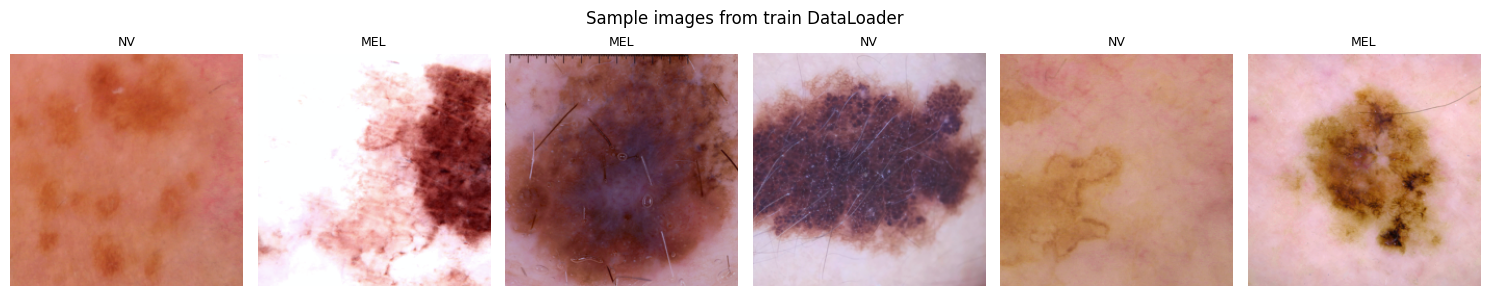

In [6]:
# ── Sanity check: visualise a batch ──────────────────────────────────────────
batch = next(iter(train_loader))
sample_imgs     = batch["image"]
sample_labels   = batch["label"]
print("Batch shape :", sample_imgs.shape)
print("Labels (raw):", sample_labels[:8].tolist())

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for i, ax in enumerate(axes):
    img = sample_imgs[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    cls = sample_labels[i].argmax().item()
    ax.imshow(img)
    ax.set_title(LABEL_NAMES[cls], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample images from train DataLoader", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
model = NVMELVAE(freeze_up_to=0).to(DEVICE)

frozen   = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Frozen parameters   : {frozen:,}")
print(f"Trainable parameters: {trainable:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]


Frozen parameters   : 0
Trainable parameters: 17,778,111


In [25]:
OVERRIDE_OPTIMIZER_AND_SCHEDULER = False

criterion = MS_SSIMLoss(channels=3, denorm_mean=imagenet_mean, denorm_std=imagenet_std).to(DEVICE)

# Only pass parameters that require gradients to the optimiser
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=0, min_lr=1e-6
)

# ── History buffers ───────────────────────────────────────────────────────────
start_epoch = 1
history     = defaultdict(list)

# ── Resume from latest checkpoint if one exists ───────────────────────────────
existing = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pth")))
if existing:
    latest = existing[-1]
    ckpt   = torch.load(latest, map_location=DEVICE, weights_only=False)

    start_epoch = ckpt["epoch"] + 1
    history = ckpt["history"]
    model.load_state_dict(ckpt["model_state"])
    if not OVERRIDE_OPTIMIZER_AND_SCHEDULER:
        optimizer.load_state_dict(ckpt["optim_state"])
        scheduler.load_state_dict(ckpt["sched_state"])
    else:
        print("Overriding checkpoint optimizer and scheduler")

    print(f"Resumed from '{latest}' (epoch {ckpt['epoch']} of {NUM_EPOCHS})")
else:
    print("No checkpoint found – starting from scratch.")

if start_epoch > NUM_EPOCHS:
    print(f"Training already complete ({NUM_EPOCHS} epochs done). Nothing to do.")

Resumed from 'checkpoints/efficientnet_nv_mel_vae/epoch_021.pth' (epoch 21 of 30)


In [26]:
# ── Training loop (checkpoints every epoch) ───────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    total        = 0

    pbar = tqdm(train_loader, desc=f"Epoch [{epoch:>3}/{NUM_EPOCHS}] train", leave=False)
    for batch in pbar:
        imgs = batch["image"].to(DEVICE, non_blocking=True)

        reconstructions = model(imgs)
        loss = criterion(reconstructions, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        total        += imgs.size(0)
        pbar.set_postfix(loss=f"{running_loss / total:.4f}")

    train_loss = running_loss / total
    history["train_losses"].append(train_loss)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0
    val_total        = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch [{epoch:>3}/{NUM_EPOCHS}] val  ", leave=False):
            imgs = batch["image"].to(DEVICE, non_blocking=True)

            reconstructions = model(imgs)
            loss = criterion(reconstructions, imgs)

            val_running_loss += loss.item() * imgs.size(0)
            val_total        += imgs.size(0)

    val_loss = val_running_loss / val_total
    history["val_losses"].append(val_loss)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch:>3}/{NUM_EPOCHS}]  "
        f"train_loss={train_loss:.4f}  "
        f"val_loss={val_loss:.4f}  "
        f"lr={scheduler.get_last_lr()[0]:.2e}"
    )

    # ── Save per-epoch checkpoint ──────────────────────────────────────────────
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pth")
    torch.save({
        "epoch"         : epoch,
        "history"       : history,
        "model_state"   : model.state_dict(),
        "optim_state"   : optimizer.state_dict(),
        "sched_state"   : scheduler.state_dict(),
    }, ckpt_path)
    print(f"  └─ Checkpoint saved: {ckpt_path}")

print("\nTraining complete.")

Epoch [ 22/30]  train_loss=0.1348  val_loss=0.1134  lr=5.00e-06
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_vae/epoch_022.pth


Epoch [ 23/30]  train_loss=0.1348  val_loss=0.1131  lr=5.00e-06
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_vae/epoch_023.pth


Epoch [ 24/30]  train_loss=0.1354  val_loss=0.1131  lr=2.50e-06
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_vae/epoch_024.pth


Epoch [ 25/30]  train_loss=0.1337  val_loss=0.1132  lr=1.25e-06
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_vae/epoch_025.pth


Epoch [ 26/30]  train_loss=0.1350  val_loss=0.1127  lr=1.25e-06
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_vae/epoch_026.pth


Epoch [ 27/30]  train_loss=0.1348  val_loss=0.1129  lr=1.00e-06
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_vae/epoch_027.pth


Epoch [ 28/30]  train_loss=0.1345  val_loss=0.1127  lr=1.00e-06
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_vae/epoch_028.pth


Epoch [ 29/30]  train_loss=0.1348  val_loss=0.1127  lr=1.00e-06
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_vae/epoch_029.pth


Epoch [ 30/30]  train_loss=0.1341  val_loss=0.1128  lr=1.00e-06
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_vae/epoch_030.pth

Training complete.


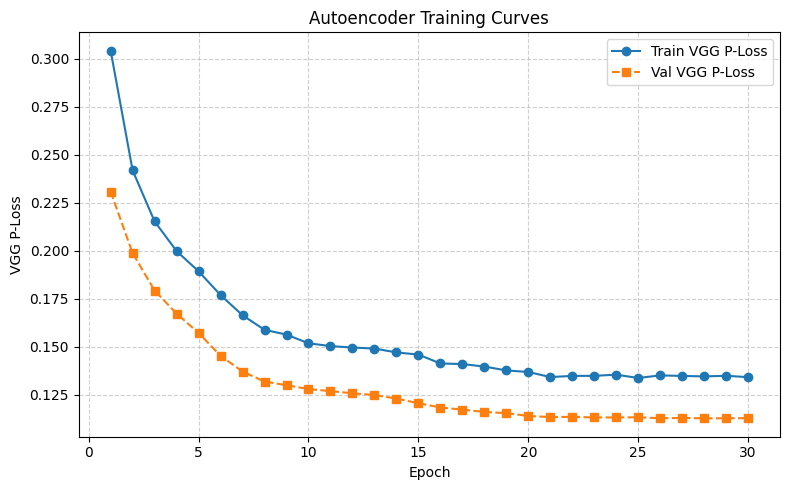

In [27]:
# ── Training curves ───────────────────────────────────────────────────────────
n_recorded = len(history["train_losses"])
epochs_x   = range(1, n_recorded + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_x, history["train_losses"], marker="o", linewidth=1.5, label="Train VGG P-Loss")
plt.plot(epochs_x, history["val_losses"],   marker="s", linewidth=1.5, label="Val VGG P-Loss",  linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("VGG P-Loss")
plt.title("Autoencoder Training Curves")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Best model loaded:
epoch: 28
train_losses: 0.13451901577260575
val_losses: 0.11267138546612596


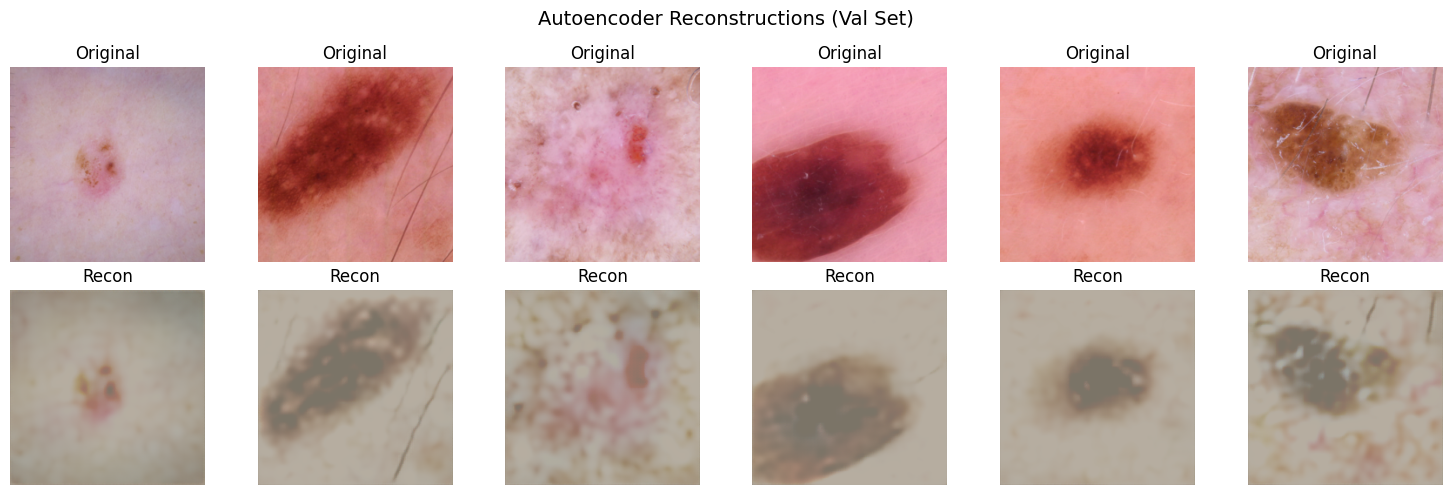

In [30]:
# Load best model and visualize reconstructions
ckpt = load_best_model(model, CHECKPOINT_DIR, lambda ckpt: np.argmin(np.array(ckpt["history"]["val_losses"])), DEVICE)
print("Best model loaded:")
print_checkpoint_info(ckpt)

model.eval()
sample_batch = next(iter(val_loader))
sample_imgs = sample_batch["image"][:6].to(DEVICE)

with torch.no_grad():
    reconstructed = model(sample_imgs)

# Move to CPU and denormalize
sample_imgs = sample_imgs.cpu()
reconstructed = reconstructed.cpu()

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

sample_imgs = (sample_imgs * std + mean).clamp(0, 1)
reconstructed = (reconstructed * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(min(6, sample_imgs.size(0))):
    # Original
    ax = axes[0, i]
    img = sample_imgs[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title("Original")
    ax.axis("off")
    
    # Reconstructed
    ax = axes[1, i]
    rec_img = reconstructed[i].permute(1, 2, 0).numpy()
    ax.imshow(rec_img)
    ax.set_title("Recon")
    ax.axis("off")

plt.suptitle("Autoencoder Reconstructions (Val Set)", fontsize=14)
plt.tight_layout()
plt.show()